# Transcript Dataset: Columns and Basic Univariate EDA

This notebook performs focused EDA on `Transcripts Machine Readable Data.csv`.

Scope:
- Column inventory and schema understanding
- Basic data quality checks (missingness, duplicates, invalid markers)
- Basic univariate analysis across all metrics
- Export of summary tables for downstream use

In [18]:
pip install fastparquet

   ---------------------------------------- 0.0/667.9 kB ? eta -:--:--
   ---------------------------------------- 667.9/667.9 kB 13.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 46.7 MB/s  0:00:00

   -------------------- ------------------- 1/2 [fastparquet]
   -------------------- ------------------- 1/2 [fastparquet]
   ---------------------------------------- 2/2 [fastparquet]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import fastparquet
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Config
candidate_paths = [
    Path("Transcripts Machine Readable Data.csv"),
    Path("Data") / "Raw Data" / "Transcripts Machine Readable Data.csv",
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), candidate_paths[0])
OUTPUT_DIR = Path("eda_outputs_transcripts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COLS = ["Symbol", "Company Name", "Metrics"]
INVALID_TOKENS = {"#INVALID COMPANY ID": np.nan, "NA": np.nan, "": np.nan}

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found. Checked: {[str(p) for p in candidate_paths]}"
    )

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Output path: {OUTPUT_DIR.resolve()}")

Data path: H:\My Drive\Project\FA Project\Data\Raw Data\Transcripts Machine Readable Data.csv
Output path: H:\My Drive\Project\FA Project\eda_outputs_transcripts


In [3]:
# Load and standardize raw structure
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw shape: {raw_df.shape}")

# Drop delimiter artifacts like unnamed trailing columns
unnamed_cols = [c for c in raw_df.columns if c.strip().lower().startswith("unnamed")]
if unnamed_cols:
    raw_df = raw_df.drop(columns=unnamed_cols)
    print(f"Dropped unnamed columns: {unnamed_cols}")

# Normalize header whitespace
raw_df.columns = [c.strip() for c in raw_df.columns]

# Normalize string cells and missing tokens
df = raw_df.copy()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip().replace(INVALID_TOKENS)

print(f"Cleaned shape: {df.shape}")
display(df.head(5))

Raw shape: (772, 48)
Dropped unnamed columns: ['Unnamed: 47']
Cleaned shape: (772, 47)


,Symbol,Company Name,Metrics,CQ12014,CQ22014,CQ32014,CQ42014,CQ12015,CQ22015,CQ32015,CQ42015,CQ12016,CQ22016,CQ32016,CQ42016,CQ12017,CQ22017,CQ32017,CQ42017,CQ12018,CQ22018,CQ32018,CQ42018,CQ12019,CQ22019,CQ32019,CQ42019,CQ12020,CQ22020,CQ32020,CQ42020,CQ12021,CQ22021,CQ32021,CQ42021,CQ12022,CQ22022,CQ32022,CQ42022,CQ12023,CQ22023,CQ32023,CQ42023,CQ12024,CQ22024,CQ32024,CQ42024
0,T,AT&T,Net Positivity,1.54,1.86,1.85,1.36,1.14,1.54,2.01,1.81,1.50,2.24,1.74,1.81,1.61,0.83,1.42,1.46,1.78,1.54,1.66,1.40,1.35,1.42,1.32,1.52,1.57,0.22,0.98,1.39,1.11,1.45,1.32,1.26,1.06,1.31,1.18,1.60,1.22,1.28,1.35,1.43,1.64,1.14,1.62,1.35
1,GOOGL,Alphabet Inc. (Class A),Net Positivity,1.42,1.37,1.25,1.48,0.97,1.82,1.68,1.56,1.74,2.03,1.90,1.95,1.90,2.24,1.80,1.77,1.81,2.06,1.96,1.72,1.95,1.66,1.61,1.78,1.70,0.72,1.58,1.87,1.63,1.89,1.70,1.38,1.85,1.63,1.56,1.35,2.11,2.25,2.50,2.34,2.50,2.52,2.44,2.22
2,GOOG,Alphabet Inc. (Class C),Net Positivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,META,Meta Platforms,Net Positivity,1.64,1.69,1.78,1.43,1.74,1.88,1.48,1.54,1.65,1.21,1.53,1.46,1.26,0.95,1.44,0.99,1.32,1.25,1.36,1.42,1.74,0.93,1.14,0.95,1.04,0.00,0.69,0.63,0.80,1.50,1.61,1.13,0.68,1.10,1.15,1.09,1.35,1.90,1.25,1.74,2.00,2.10,2.40,2.02
4,NFLX,Netflix,Net Positivity,0.98,1.22,1.38,0.50,0.98,0.99,1.19,1.16,1.10,1.22,0.84,1.05,1.69,1.60,2.00,1.53,1.31,1.38,1.80,1.15,1.66,1.86,1.74,1.66,1.36,1.14,2.00,0.97,1.34,1.52,1.35,1.96,1.29,1.51,1.55,1.49,1.79,1.95,1.50,1.61,1.78,1.96,2.32,2.18


In [4]:
# Column inventory and data dictionary
quarter_cols = [c for c in df.columns if c.startswith("CQ")]
non_quarter_cols = [c for c in df.columns if c not in quarter_cols]

column_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
})

column_dict["role"] = np.where(
    column_dict["column"].isin(quarter_cols),
    "quarter_value",
    np.where(column_dict["column"].isin(ID_COLS), "identifier", "other"),
)

print(f"Total columns: {len(df.columns)}")
print(f"Quarter columns: {len(quarter_cols)}")
if quarter_cols:
    print(f"Quarter range: {quarter_cols[0]} to {quarter_cols[-1]}")

display(column_dict.sort_values(["role", "column"]).reset_index(drop=True))

column_dict.to_csv(OUTPUT_DIR / "column_dictionary_and_schema.csv", index=False)

Total columns: 47
Quarter columns: 44
Quarter range: CQ12014 to CQ42024


,column,dtype,missing_count,missing_pct,n_unique,role
0,Company Name,object,0,0.00,193,identifier
1,Metrics,object,0,0.00,4,identifier
2,Symbol,object,0,0.00,193,identifier
3,CQ12014,object,8,1.04,506,quarter_value
4,CQ12015,object,8,1.04,510,quarter_value
5,CQ12016,object,8,1.04,500,quarter_value
6,CQ12017,object,8,1.04,510,quarter_value
7,CQ12018,object,8,1.04,477,quarter_value
8,CQ12019,object,8,1.04,508,quarter_value
9,CQ12020,object,8,1.04,474,quarter_value


In [5]:
# Basic quality checks
missing_summary = (
    df.isna().sum().rename("missing_count").to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)

# Duplicate check at business key
dup_key_cols = [c for c in ID_COLS if c in df.columns]
key_dup_count = int(df.duplicated(subset=dup_key_cols).sum()) if dup_key_cols else np.nan

# Rows where all quarter values are missing
all_quarter_missing_count = int(df[quarter_cols].isna().all(axis=1).sum()) if quarter_cols else np.nan

print(f"Duplicate rows by key {dup_key_cols}: {key_dup_count}")
print(f"Rows with all quarter values missing: {all_quarter_missing_count}")

display(missing_summary.head(30))

missing_summary.to_csv(OUTPUT_DIR / "missingness_summary.csv")

Duplicate rows by key ['Symbol', 'Company Name', 'Metrics']: 0
Rows with all quarter values missing: 8


,missing_count,missing_pct
CQ32014,8,1.04
CQ22014,8,1.04
CQ12014,8,1.04
CQ42014,8,1.04
CQ32015,8,1.04
CQ22015,8,1.04
CQ12015,8,1.04
CQ12016,8,1.04
CQ22016,8,1.04
CQ32016,8,1.04


In [6]:
# Reshape to long format for univariate analysis
long_df = df.melt(
    id_vars=[c for c in ID_COLS if c in df.columns],
    value_vars=quarter_cols,
    var_name="quarter",
    value_name="value",
)

# Parse quarter to date (quarter end)
quarter_pattern = long_df["quarter"].str.extract(r"^CQ([1-4])(\d{4})$")
long_df["quarter_num"] = pd.to_numeric(quarter_pattern[0], errors="coerce")
long_df["year"] = pd.to_numeric(quarter_pattern[1], errors="coerce")
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
long_df["quarter_end"] = pd.to_datetime(
    dict(year=long_df["year"], month=long_df["quarter_num"].map(month_map), day=1),
    errors="coerce",
) + pd.offsets.MonthEnd(0)

long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")

dup_long = int(long_df.duplicated(subset=["Symbol", "Metrics", "quarter"]).sum())
print(f"Long shape: {long_df.shape}")
print(f"Duplicate (Symbol, Metrics, quarter) in long data: {dup_long}")
display(long_df.head())

long_df.to_csv(OUTPUT_DIR / "transcripts_long_panel.csv", index=False)

Long shape: (33968, 8)
Duplicate (Symbol, Metrics, quarter) in long data: 0


,Symbol,Company Name,Metrics,quarter,value,quarter_num,year,quarter_end
0,T,AT&T,Net Positivity,CQ12014,1.54,1,2014,2014-03-31
1,GOOGL,Alphabet Inc. (Class A),Net Positivity,CQ12014,1.42,1,2014,2014-03-31
2,GOOG,Alphabet Inc. (Class C),Net Positivity,CQ12014,NaN,1,2014,2014-03-31
3,META,Meta Platforms,Net Positivity,CQ12014,1.64,1,2014,2014-03-31
4,NFLX,Netflix,Net Positivity,CQ12014,0.98,1,2014,2014-03-31


In [7]:
# Basic univariate summary by metric
metric_summary = (
    long_df.groupby("Metrics")["value"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)

metric_missing = (
    long_df.groupby("Metrics", as_index=False)
    .agg(total_obs=("value", "size"), non_missing_obs=("value", "count"))
)
metric_missing["missing_obs"] = metric_missing["total_obs"] - metric_missing["non_missing_obs"]
metric_missing["missing_pct"] = (metric_missing["missing_obs"] / metric_missing["total_obs"] * 100).round(2)

display(metric_summary)
display(metric_missing.sort_values("missing_pct", ascending=False))

# metric_summary.to_csv(OUTPUT_DIR / "metric_univariate_summary.csv", index=False)
# metric_missing.to_csv(OUTPUT_DIR / "metric_missingness_summary.csv", index=False)

,Metrics,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,Analyst Selectivity Ratio,8120.0,41.818329,16.358235,0.00,4.55,17.50,30.00,40.00,52.94,69.23,81.7117,100.00
1,Language Complexity,8117.0,12.422687,1.136442,9.05,10.10,10.68,11.62,12.37,13.14,14.42,15.3200,17.74
2,Net Positivity,8117.0,1.105240,0.594777,-1.43,-0.37,0.14,0.73,1.11,1.49,2.06,2.5500,3.32
3,Numeric Transeprency,8117.0,2.328527,0.762707,0.29,0.90,1.25,1.79,2.25,2.78,3.66,4.5100,7.46


,Metrics,total_obs,non_missing_obs,missing_obs,missing_pct
1,Language Complexity,8492,8117,375,4.42
2,Net Positivity,8492,8117,375,4.42
3,Numeric Transeprency,8492,8117,375,4.42
0,Analyst Selectivity Ratio,8492,8120,372,4.38


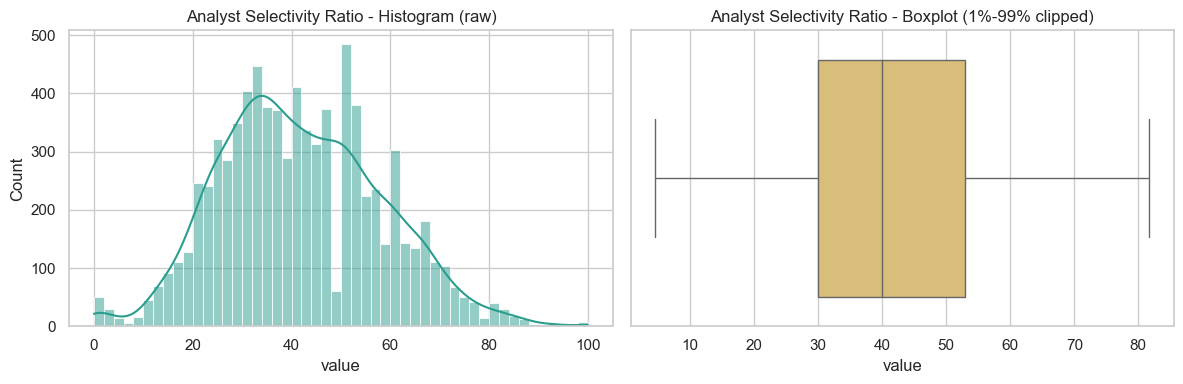

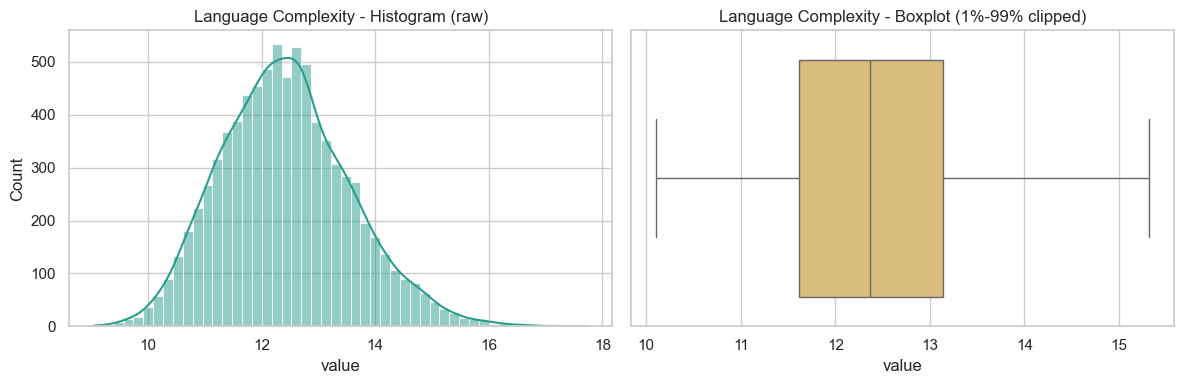

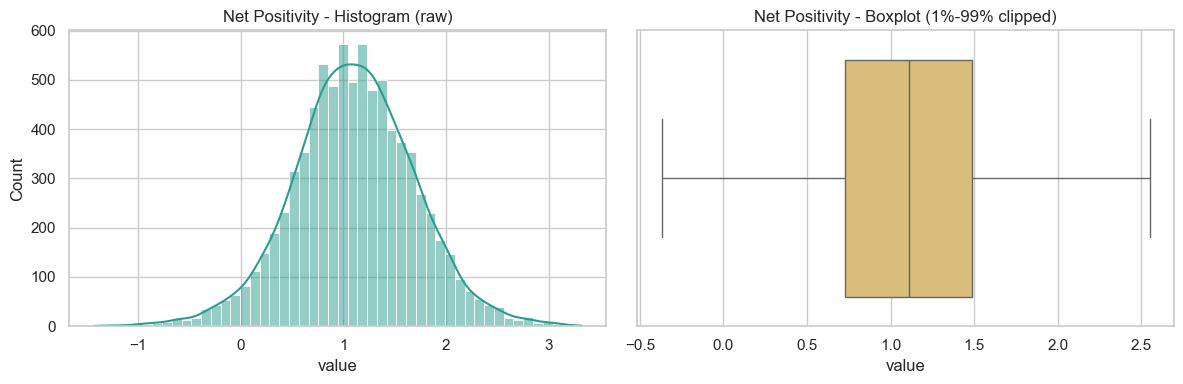

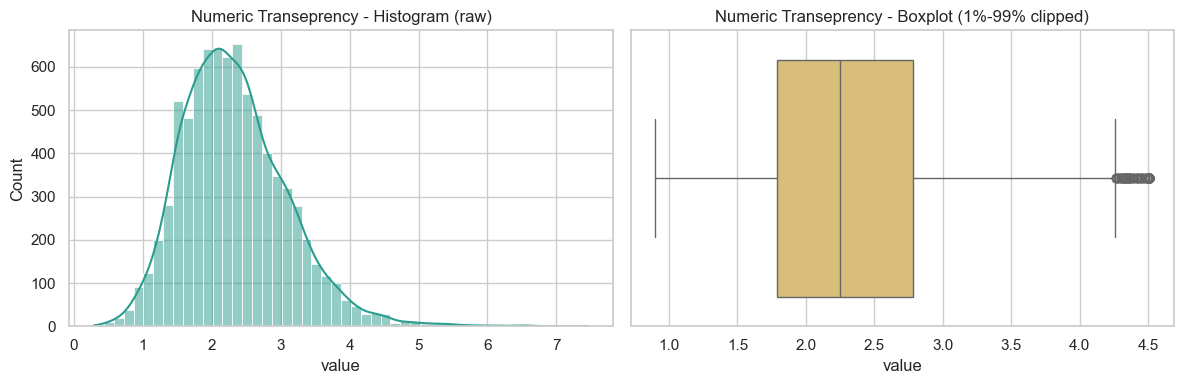

In [8]:
# Basic plots: distribution by metric (clipped for readability)
metrics = sorted(long_df["Metrics"].dropna().unique())

for metric in metrics:
    s = long_df.loc[long_df["Metrics"] == metric, "value"].dropna()
    if s.empty:
        continue

    p1, p99 = s.quantile([0.01, 0.99])
    clipped = s.clip(lower=p1, upper=p99)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(s, bins=50, kde=True, ax=axes[0], color="#2A9D8F")
    axes[0].set_title(f"{metric} - Histogram (raw)")

    sns.boxplot(x=clipped, ax=axes[1], color="#E9C46A")
    axes[1].set_title(f"{metric} - Boxplot (1%-99% clipped)")

    plt.tight_layout()
    plt.show()

,quarter,non_missing_obs
0,CQ12014,744
1,CQ12015,744
2,CQ12016,732
3,CQ12017,740
4,CQ12018,736
5,CQ12019,740
6,CQ12020,731
7,CQ12021,744
8,CQ12022,736
9,CQ12023,744


,quarter,Metrics,median_value
0,CQ12014,Analyst Selectivity Ratio,41.280
1,CQ12014,Language Complexity,12.305
2,CQ12014,Net Positivity,0.970
3,CQ12014,Numeric Transeprency,2.720
4,CQ12015,Analyst Selectivity Ratio,42.210
5,CQ12015,Language Complexity,12.350
6,CQ12015,Net Positivity,1.015
7,CQ12015,Numeric Transeprency,2.845
8,CQ12016,Analyst Selectivity Ratio,41.670
9,CQ12016,Language Complexity,12.450


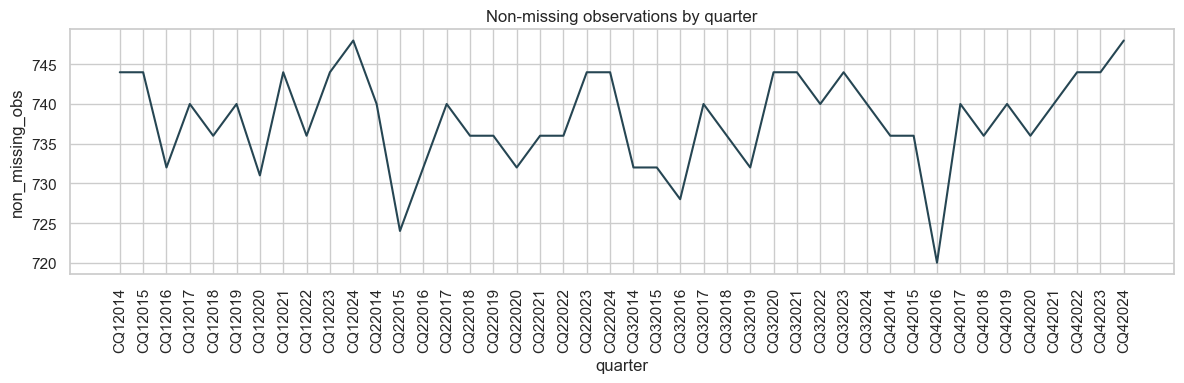

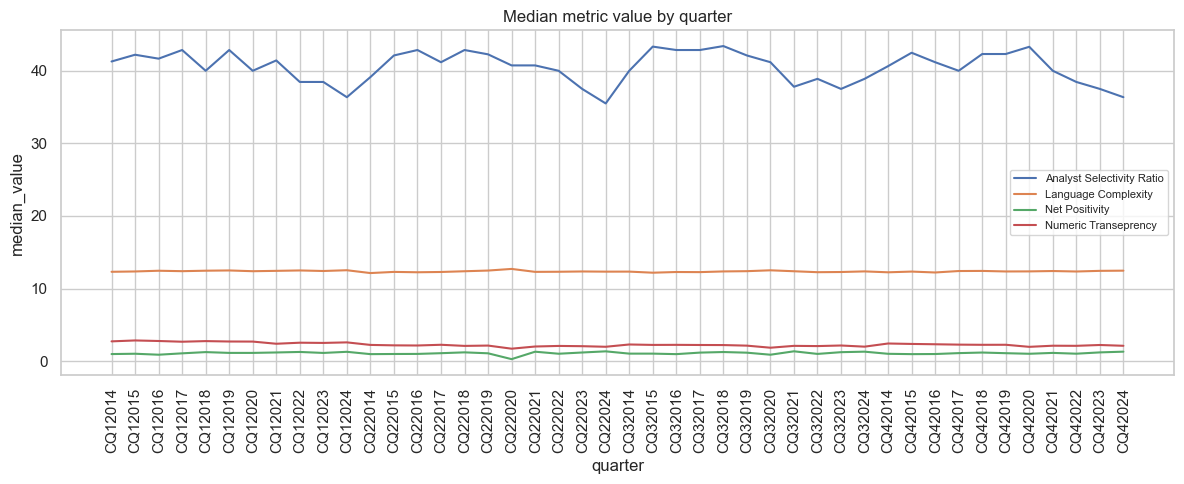

Saved outputs:
- column_dictionary_and_schema.csv
- metric_missingness_summary.csv
- metric_univariate_summary.csv
- missingness_summary.csv
- quarter_metric_medians.csv
- quarter_non_missing_counts.csv
- transcripts_long_panel.csv


In [9]:
# Basic time univariate views
quarter_counts = (
    long_df.groupby("quarter", as_index=False)
    .agg(non_missing_obs=("value", "count"))
    .sort_values("quarter")
)

quarter_median_by_metric = (
    long_df.groupby(["quarter", "Metrics"], as_index=False)["value"]
    .median()
    .rename(columns={"value": "median_value"})
)

display(quarter_counts.head(12))
display(quarter_median_by_metric.head(20))

plt.figure(figsize=(12, 4))
sns.lineplot(data=quarter_counts, x="quarter", y="non_missing_obs", color="#264653")
plt.title("Non-missing observations by quarter")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(data=quarter_median_by_metric, x="quarter", y="median_value", hue="Metrics")
plt.title("Median metric value by quarter")
plt.xticks(rotation=90)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

# quarter_counts.to_csv(OUTPUT_DIR / "quarter_non_missing_counts.csv", index=False)
# quarter_median_by_metric.to_csv(OUTPUT_DIR / "quarter_metric_medians.csv", index=False)

print("Saved outputs:")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p.name)

## Interpretation Notes (Fill After Run)

Use this section to summarize:
- Which columns are identifiers vs quarter values
- Where missingness is concentrated
- Which metrics are most/least volatile from univariate summaries
- Any obvious outliers or unusual ranges
- Whether the dataset is clean enough for downstream feature work

## Next-Quarter Forecasting Pipeline (LightGBM, Random Forest, CatBoost, XGBoost)

This section builds a leakage-safe quarterly panel to predict the **next-quarter metric value** (`target_next_q`) for each `Symbol` and `Metrics` series.

Workflow:
1. Build canonical quarterly panel and deduplicate keys
2. Time-aware feature imputation (`ffill` within series + train-only metric medians)
3. Feature engineering (lags, deltas, trailing stats)
4. Chronological train/validation/test splits
5. Train and compare four models with consistent metrics

In [10]:
# Forecasting setup: dependencies, quarterly panel build, imputation, feature engineering, and splits
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

missing_pkgs = []

try:
    from lightgbm import LGBMRegressor
except ImportError:
    missing_pkgs.append("lightgbm")

try:
    from xgboost import XGBRegressor
except ImportError:
    missing_pkgs.append("xgboost")

try:
    from catboost import CatBoostRegressor
except ImportError:
    missing_pkgs.append("catboost")

if missing_pkgs:
    raise ImportError(
        "Missing required packages: "
        + ", ".join(missing_pkgs)
        + ". Install with: pip install "
        + " ".join(missing_pkgs)
    )

# 1) Canonical quarterly panel at (Symbol, Metrics, quarter_end)
q_panel = (
    long_df[["Symbol", "Metrics", "quarter", "quarter_end", "quarter_num", "year", "value"]]
    .dropna(subset=["quarter_end"])
    .copy()
)

# Deduplicate keys by median value in case repeated records exist in the same quarter
q_panel = (
    q_panel.groupby(["Symbol", "Metrics", "quarter", "quarter_end", "quarter_num", "year"], as_index=False)["value"]
    .median()
)

q_panel = q_panel.sort_values(["Symbol", "Metrics", "quarter_end"]).reset_index(drop=True)
series_cols = ["Symbol", "Metrics"]

# Keep explicit missing indicator before any imputation
q_panel["value_missing_raw"] = q_panel["value"].isna().astype("int8")

# 2) Time-aware forward fill within each Symbol + Metrics series (no backward fill)
q_panel["value_ffill"] = q_panel.groupby(series_cols)["value"].transform(lambda s: s.ffill())

# 3) Build next-quarter target from observed value only (drop unavailable targets)
q_panel["target_next_q"] = q_panel.groupby(series_cols)["value"].shift(-1)

# 4) Leakage-safe lag and trailing features from time-ordered value_ffill
for lag in [1, 2, 4]:
    q_panel[f"lag{lag}_value"] = q_panel.groupby(series_cols)["value_ffill"].shift(lag)

q_panel["delta_lag1_lag2"] = q_panel["lag1_value"] - q_panel["lag2_value"]
q_panel["roll4_mean"] = (
    q_panel.groupby(series_cols)["value_ffill"]
    .transform(lambda s: s.shift(1).rolling(window=4, min_periods=2).mean())
)
q_panel["roll4_std"] = (
    q_panel.groupby(series_cols)["value_ffill"]
    .transform(lambda s: s.shift(1).rolling(window=4, min_periods=2).std())
)

# Final modeling frame: target must be present (next quarter exists)
model_df = q_panel.dropna(subset=["target_next_q"]).copy()

# 5) Chronological split by year: train(<=2021), val(2022-2023), test(>=2024)
train_mask = model_df["year"] <= 2021
val_mask = model_df["year"].between(2022, 2023)
test_mask = model_df["year"] >= 2024

train_df = model_df.loc[train_mask].copy()
val_df = model_df.loc[val_mask].copy()
test_df = model_df.loc[test_mask].copy()

if train_df.empty or val_df.empty or test_df.empty:
    raise ValueError(
        "One or more splits are empty. Check quarter coverage or adjust year boundaries."
    )

# 6) Train-only median imputation by Metrics for numeric feature columns
feature_num_cols = [
    "quarter_num",
    "year",
    "value_missing_raw",
    "value_ffill",
    "lag1_value",
    "lag2_value",
    "lag4_value",
    "delta_lag1_lag2",
    "roll4_mean",
    "roll4_std",
]

metric_medians = train_df.groupby("Metrics")[feature_num_cols].median()
global_medians = train_df[feature_num_cols].median()


def fill_numeric_by_metric(df_in, medians_by_metric, fallback_medians, num_cols):
    df_out = df_in.copy()
    for col in num_cols:
        mapped = df_out["Metrics"].map(medians_by_metric[col])
        df_out[col] = df_out[col].fillna(mapped)
        df_out[col] = df_out[col].fillna(fallback_medians[col])
    return df_out


train_df = fill_numeric_by_metric(train_df, metric_medians, global_medians, feature_num_cols)
val_df = fill_numeric_by_metric(val_df, metric_medians, global_medians, feature_num_cols)
test_df = fill_numeric_by_metric(test_df, metric_medians, global_medians, feature_num_cols)

# Feature set used by all models
base_feature_cols = ["Symbol", "Metrics"] + feature_num_cols

y_train = train_df["target_next_q"].astype(float)
y_val = val_df["target_next_q"].astype(float)
y_test = test_df["target_next_q"].astype(float)

# One-hot encoding for non-CatBoost models
all_non_cat = pd.concat(
    [train_df[base_feature_cols], val_df[base_feature_cols], test_df[base_feature_cols]],
    axis=0,
)
all_non_cat = pd.get_dummies(all_non_cat, columns=["Symbol", "Metrics"], dtype=float)

n_train = len(train_df)
n_val = len(val_df)

X_train_non_cat = all_non_cat.iloc[:n_train].reset_index(drop=True)
X_val_non_cat = all_non_cat.iloc[n_train:n_train + n_val].reset_index(drop=True)
X_test_non_cat = all_non_cat.iloc[n_train + n_val:].reset_index(drop=True)

# Raw features for CatBoost with native categorical handling
X_train_cat = train_df[base_feature_cols].copy()
X_val_cat = val_df[base_feature_cols].copy()
X_test_cat = test_df[base_feature_cols].copy()

cat_features = ["Symbol", "Metrics"]

print("Prepared modeling datasets:")
print("- Train rows:", len(train_df), "| quarters:", train_df["quarter"].nunique())
print("- Val rows:", len(val_df), "| quarters:", val_df["quarter"].nunique())
print("- Test rows:", len(test_df), "| quarters:", test_df["quarter"].nunique())
print("- Non-Cat features:", X_train_non_cat.shape[1])

Prepared modeling datasets:
- Train rows: 23551 | quarters: 32
- Val rows: 5944 | quarters: 8
- Test rows: 2232 | quarters: 3
- Non-Cat features: 201


In [11]:
# Train all four models and compare metrics

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


def directional_accuracy(df_split, y_true, y_pred):
    # Direction of QoQ movement from previous quarter (lag1)
    prev_q = df_split["lag1_value"].to_numpy()
    true_move = np.sign(np.asarray(y_true) - prev_q)
    pred_move = np.sign(np.asarray(y_pred) - prev_q)
    return float((true_move == pred_move).mean())


models = {}

models["LightGBM"] = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

models["RandomForest"] = RandomForestRegressor(
    n_estimators=400,
    max_depth=18,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)

models["XGBoost"] = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
)

models["CatBoost"] = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)

fitted_models = {}
records = []

for name, model in models.items():
    if name == "CatBoost":
        model.fit(
            X_train_cat,
            y_train,
            cat_features=cat_features,
            eval_set=(X_val_cat, y_val),
            use_best_model=True,
        )
        pred_val = model.predict(X_val_cat)
        pred_test = model.predict(X_test_cat)
    else:
        fit_kwargs = {}
        if name in {"LightGBM", "XGBoost"}:
            fit_kwargs["eval_set"] = [(X_val_non_cat, y_val)]

        if name == "LightGBM":
            fit_kwargs["callbacks"] = []

        model.fit(X_train_non_cat, y_train, **fit_kwargs)
        pred_val = model.predict(X_val_non_cat)
        pred_test = model.predict(X_test_non_cat)

    fitted_models[name] = {
        "model": model,
        "pred_val": pred_val,
        "pred_test": pred_test,
    }

    mae_val, rmse_val = regression_metrics(y_val, pred_val)
    mae_test, rmse_test = regression_metrics(y_test, pred_test)

    dacc_val = directional_accuracy(val_df, y_val, pred_val)
    dacc_test = directional_accuracy(test_df, y_test, pred_test)

    records.append(
        {
            "model": name,
            "val_mae": mae_val,
            "val_rmse": rmse_val,
            "val_directional_acc": dacc_val,
            "test_mae": mae_test,
            "test_rmse": rmse_test,
            "test_directional_acc": dacc_test,
        }
    )

model_comparison = pd.DataFrame(records).sort_values("test_mae").reset_index(drop=True)
display(model_comparison)

# Export model comparison and scored test panel
model_output_dir = OUTPUT_DIR / "modeling_quarterly"
model_output_dir.mkdir(parents=True, exist_ok=True)

model_comparison.to_csv(model_output_dir / "model_comparison_next_quarter.csv", index=False)

best_model_name = model_comparison.loc[0, "model"]
best_test_pred = fitted_models[best_model_name]["pred_test"]

scored_test = test_df[["Symbol", "Metrics", "quarter", "quarter_end", "target_next_q", "lag1_value"]].copy()
scored_test["prediction_next_q"] = best_test_pred
scored_test["abs_error"] = (scored_test["target_next_q"] - scored_test["prediction_next_q"]).abs()

scored_test.to_csv(model_output_dir / "best_model_test_predictions.csv", index=False)

print("Saved modeling outputs:")
print("-", (model_output_dir / "model_comparison_next_quarter.csv").name)
print("-", (model_output_dir / "best_model_test_predictions.csv").name)
print("Best model by test MAE:", best_model_name)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000585 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2181
[LightGBM] [Info] Number of data points in the train set: 23551, number of used features: 200
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 14.623445
[0]	validation_0-rmse:16.93321
[1]	validation_0-rmse:16.45757
[2]	validation_0-rmse:15.99566
[3]	validation_0-rmse:15.54874
[4]	validation_0-rmse:15.11743
[5]	validation_0-rmse:14.69848
[6]	validation_0-rmse:14.29431
[7]	validation_0-rmse:13.90353
[8]	validation_0-rmse:13.53002
[9]	validation_0-rmse:13.16889
[10]	validation_0-rmse:12.81442
[11]	validation_0-rmse:12.47343
[12]	validation_0-rmse:12.14466
[13]	validation_0-rmse:11.

,model,val_mae,val_rmse,val_directional_acc,test_mae,test_rmse,test_directional_acc
0,CatBoost,2.079746,4.791045,0.688257,2.093900,4.977006,0.681004
1,RandomForest,2.078078,4.862995,0.698856,2.144575,5.050511,0.689068
2,XGBoost,2.074797,4.838197,0.705585,2.163848,5.137202,0.689516
3,LightGBM,2.178760,5.020562,0.694650,2.244515,5.296020,0.678763


Saved modeling outputs:
- model_comparison_next_quarter.csv
- best_model_test_predictions.csv
Best model by test MAE: CatBoost


In [21]:
# Export long_df to Parquet (writes to eda_outputs_transcripts)
import subprocess
import sys
import tempfile

parquet_path = OUTPUT_DIR / "transcripts_long_panel.parquet"
export_df = long_df.copy()
period_cols = [c for c in export_df.columns if pd.api.types.is_period_dtype(export_df[c])]
for col in period_cols:
    export_df[col] = export_df[col].astype(str)

try:
    export_df.to_parquet(parquet_path, index=False, engine="fastparquet")
    print(f"Saved parquet with fastparquet: {parquet_path}")
except Exception as first_error:
    print("Fastparquet export failed:", first_error)
    with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as tmp_file:
        temp_pickle_path = Path(tmp_file.name)
    export_df.to_pickle(temp_pickle_path)
    child_script = (
        "from pathlib import Path\n"
        "import pandas as pd\n"
        "import sys\n"
        "df = pd.read_pickle(Path(sys.argv[1]))\n"
        "df.to_parquet(Path(sys.argv[2]), index=False, engine='pyarrow')\n"
    )
    subprocess.run([sys.executable, "-c", child_script, str(temp_pickle_path), str(parquet_path)], check=True)
    temp_pickle_path.unlink(missing_ok=True)
    print(f"Saved parquet from a fresh Python process: {parquet_path}")

Saved parquet with fastparquet: eda_outputs_transcripts\transcripts_long_panel.parquet
